In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import datasets
from tensorflow.keras.utils import to_categorical

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
Y_train = to_categorical(y_train)
Y_test = to_categorical(y_test)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [4]:
img_rows, img_cols, _ = X_train.shape[1:]
input_shape = (img_rows, img_cols, 3)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
print(Y_train[0])
num_classes = 10
batch_size = 32
print(input_shape)


[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
(32, 32, 3)


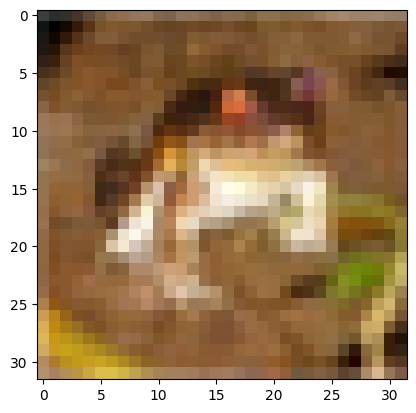

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])
plt.show()

In [6]:
# functional api model

x = layers.Input(shape=input_shape,  name='input')
h = layers.Conv2D(32, kernel_size=(3, 3), activation='relu',  name='conv1')(x)
h = layers.Dropout(0.2)(h)
h = layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', name='conv2')(h)
h = layers.MaxPooling2D(pool_size=(2, 2), name='pool1')(h)
h = layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same', name='conv3')(h)
h = layers.MaxPooling2D(pool_size=(2, 2), name='pool2')(h)
h = layers.Flatten()(h)
h = layers.Dropout(0.2)(h)
h = layers.Dense(512, activation='relu', name='poolhidden')(h)
h = layers.Dropout(0.2)(h)
y = layers.Dense(num_classes, activation='softmax', name='output')(h)

model = models.Model(x, y)
print(model.summary())


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ poolhidden (Dense)              │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,639,914 (6.26 MB)

 Trainable params: 1,639,914 (6.26 MB)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
batch_size

32

In [8]:
epochs = 25
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, Y_train, batch_size=batch_size,
          epochs=epochs, validation_split=0.1, verbose=2)

score = model.evaluate(X_test, Y_test)
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/25
1407/1407 - 16s - 12ms/step - accuracy: 0.4817 - loss: 1.4370 - val_accuracy: 0.6274 - val_loss: 1.0604
Epoch 2/25
1407/1407 - 4s - 3ms/step - accuracy: 0.6518 - loss: 0.9910 - val_accuracy: 0.6974 - val_loss: 0.8937
Epoch 3/25
1407/1407 - 4s - 3ms/step - accuracy: 0.7171 - loss: 0.8069 - val_accuracy: 0.7306 - val_loss: 0.7683
Epoch 4/25
1407/1407 - 4s - 3ms/step - accuracy: 0.7607 - loss: 0.6867 - val_accuracy: 0.7558 - val_loss: 0.7029
Epoch 5/25
1407/1407 - 4s - 3ms/step - accuracy: 0.7940 - loss: 0.5888 - val_accuracy: 0.7598 - val_loss: 0.7063
Epoch 6/25
1407/1407 - 4s - 3ms/step - accuracy: 0.8249 - loss: 0.4960 - val_accuracy: 0.7526 - val_loss: 0.7529
Epoch 7/25
1407/1407 - 4s - 3ms/step - accuracy: 0.8482 - loss: 0.4282 - val_accuracy: 0.7666 - val_loss: 0.7727
Epoch 8/25
1407/1407 - 4s - 3ms/step - accuracy: 0.8681 - loss: 0.3680 - val_accuracy: 0.7586 - val_loss: 0.8129
Epoch 9/25
1407/1407 - 4s - 3ms/step - accuracy: 0.8841 - loss: 0.3272 - val_accuracy: 0.7498 

In [9]:
print(model.layers[1].name)

conv1


In [10]:
import numpy as np
conv1 = model.layers[1].get_weights()
conv1

[array([[[[-1.36111736e-01,  3.92800244e-03,  1.61480382e-02,
           -1.06110550e-01, -1.51747495e-01, -1.26497135e-01,
           -1.83861271e-01, -2.32369363e-01,  1.12077199e-01,
            7.65668526e-02,  1.51312426e-01, -1.18139118e-01,
           -7.02831745e-02, -7.84889832e-02,  6.02261201e-02,
            1.78500712e-01, -2.67407835e-01,  2.37448096e-01,
            6.64896742e-02,  4.83276807e-02,  1.71459720e-01,
            8.87398049e-02, -2.57974654e-01,  7.51998797e-02,
           -1.20848380e-01, -1.00385673e-01, -3.30090262e-02,
           -4.60151844e-02,  2.07429200e-01,  7.56734237e-02,
           -3.46294865e-02, -1.01155691e-01],
          [ 3.84371355e-02, -7.94856250e-02,  1.71847552e-01,
           -1.53103232e-01,  2.78425403e-02, -1.11780397e-03,
           -2.78446376e-01, -3.33499238e-02,  2.66185701e-01,
            1.59757987e-01,  2.47049615e-01,  8.44425056e-03,
           -1.96837261e-01, -1.22354314e-01,  1.06690712e-01,
           -2.06744120e-

In [11]:
conv1[0].shape, conv1[1].shape # (3*3*3+1)*32개의 parameters

((3, 3, 3, 32), (32,))